In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [8]:
plt.style.use('seaborn-v0_8')

In [3]:
data = pd.read_csv('smaller.csv', dtype={'SOCP': str})
data['inc2024'] = data.PINCP * data.ADJINC / 1_000_000
data.shape, data.PWGTP.sum()

((3422888, 7), np.int64(340110990))

In [4]:
data = data.dropna(subset=['PWGTP', 'ADJINC', 'PINCP'])
data.shape, data.PWGTP.sum()

((2912790, 7), np.int64(280613270))

In [5]:
data = data[data.inc2024 > 0]
data.shape, data.PWGTP.sum()

((2556439, 7), np.int64(245168158))

In [6]:
data.PWGTP[data.inc2024 > 500_000].sum()

np.int64(1932186)

In [11]:
data[data.SOCP.str.startswith('25')].head()

,PWGTP,ADJINC,AGEP,PINCP,OCCP,SOCP,inc2024
46,62,1015250,21,1800.0,2350.0,253041,1827.45
149,74,1015250,18,800.0,2300.0,252010,812.20
175,57,1015250,24,22000.0,2545.0,259040,22335.50
181,6,1015250,18,800.0,2300.0,252010,812.20
189,63,1015250,19,2200.0,2350.0,253041,2233.55


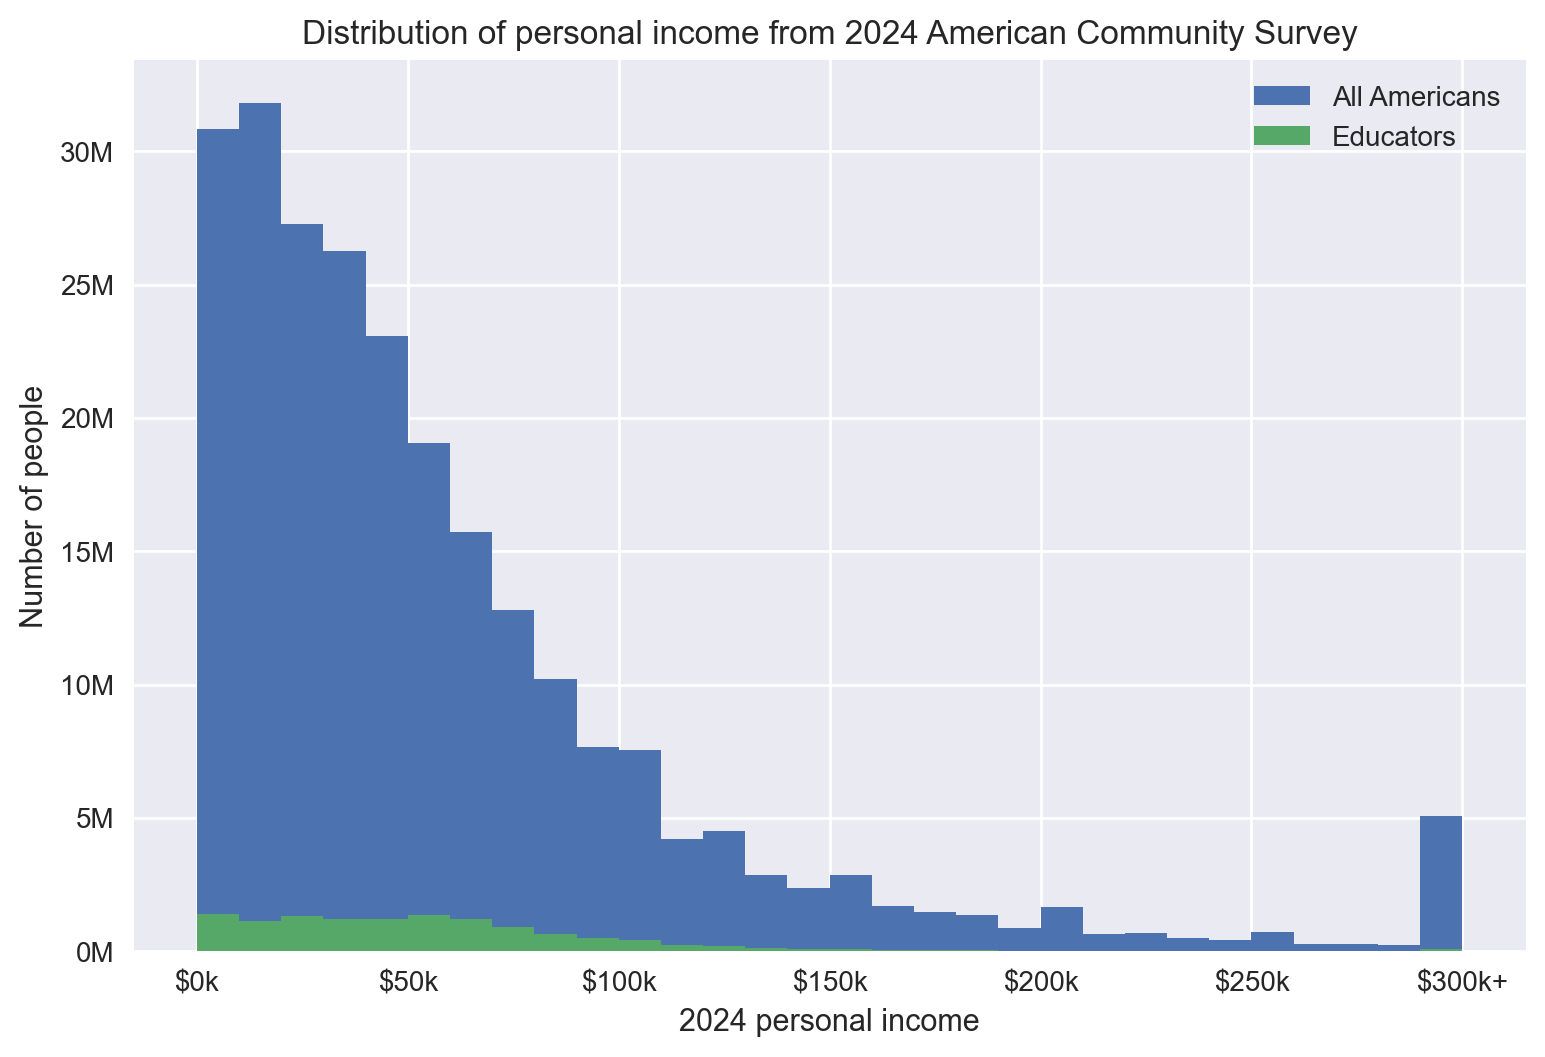

In [33]:
bins = range(0, 310_000, 10_000)

def fmt(x, _):
    label = f'${int(x/1000)}k'
    if x == 300000:
        label += '+'
    return label

plt.hist(
    data.inc2024.clip(upper=300_000),
    weights=data.PWGTP,
    bins=bins,
    label='All Americans')
subset_selector = data.SOCP.str.startswith('25')
plt.hist(
    data.inc2024.clip(upper=300_000)[subset_selector],
    weights=data.PWGTP[subset_selector],
    bins=bins,
    label='Educators')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(fmt))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.xlabel('2024 personal income')
plt.ylabel('Number of people')
plt.legend()
plt.title('Distribution of personal income based on 2024 American Community Survey')
plt.show()

In [18]:
list(range(0, 310000, 10000))

[0,
 10000,
 20000,
 30000,
 40000,
 50000,
 60000,
 70000,
 80000,
 90000,
 100000,
 110000,
 120000,
 130000,
 140000,
 150000,
 160000,
 170000,
 180000,
 190000,
 200000,
 210000,
 220000,
 230000,
 240000,
 250000,
 260000,
 270000,
 280000,
 290000,
 300000]

In [6]:
data.PWGTP.max()

np.int64(2300)

<Axes: >

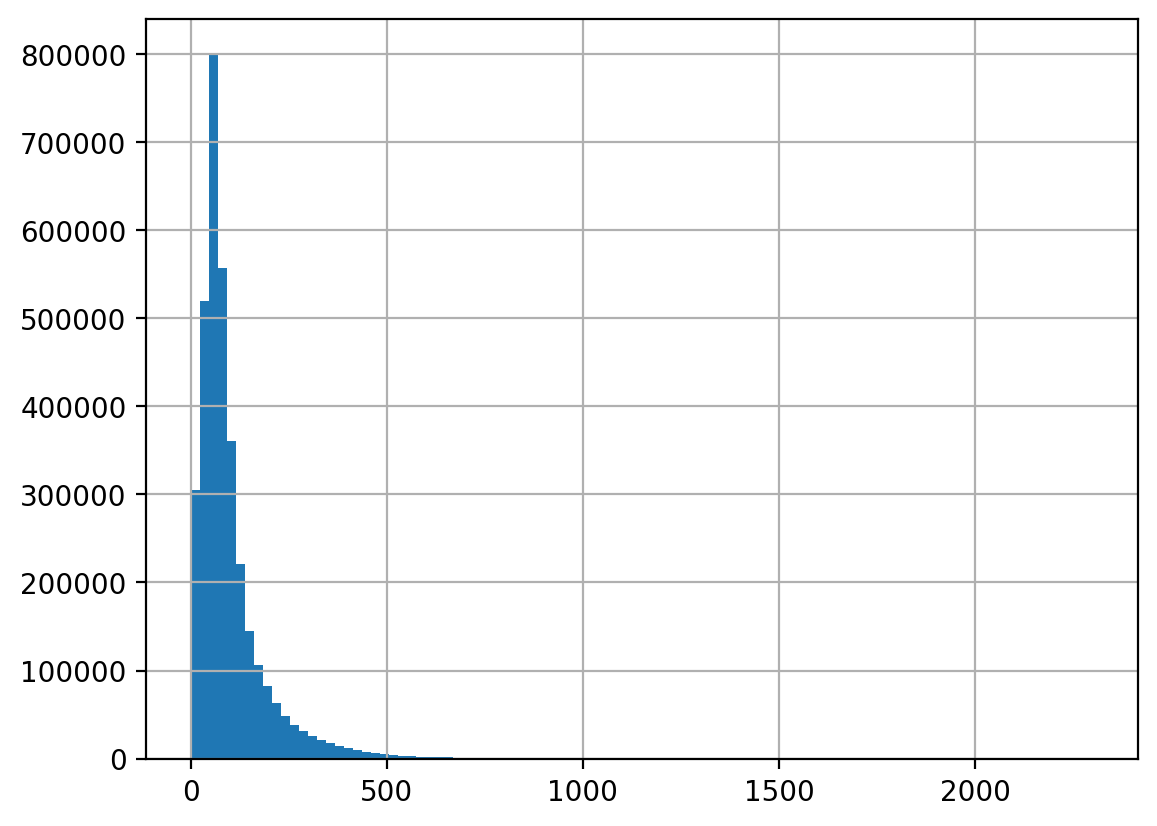

In [8]:
data.PWGTP.hist(bins=100)

In [12]:
data.PINCP.min() # no "-19999" NA values...

np.float64(-11500.0)

In [13]:
data.PINCP.max()  # screams for log but hmm...

np.float64(1945000.0)

In [14]:
data.PINCP.isna().sum()

np.int64(510098)

In [15]:
(data.PINCP == 0).sum()

np.int64(353415)

In [16]:
(data.PINCP < 0).sum()

np.int64(2936)

In [ ]:
plt.hist(data.PINCP
plt.show()